---
# <font color="#CA3532">Deep Learning Fundamentals and Basic Tools (2026/2027) - Lab Assignment 2</font>
---


* This assignment is centered on the use of [Keras](https://keras.io/).

* Keras is an open-source deep learning library designed to make the development and experimentation of neural networks simple, fast, and intuitive. It provides a user-friendly, modular, and extensible interface.

* Keras can run on top of different computational backends. In this assignment, we will use **TensorFlow** as the backend.

* Throughout the assignment, we will see how easily neural networks can be created with Keras and explore some of the many configuration options available, including network architecture, activation functions, optimizers, and regularization techniques.

### <font color="#CA3532">Instructions</font>

Before You Start the Project

It is strongly recommended that you first clone the entire repository using the following command and read the [`README.md`](https://github.com/samanemami/DLFBT-LAB/blob/main/README.md) file before starting the project.

!git clone https://github.com/samanemami/DLFBT-LAB.git


Keep `lab2_2026.ipynb` and `dlfbt_lab2.py` in the same directory.

### <font color="#CA3532">Imports and reproducibility</font>

In [1]:
import os
import sys
import importlib
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

sys.path.append("../")

import config

solution = importlib.import_module(
    config.get_source_module(lab_number=2)
)

solution.set_reproducible(42)

print("Loaded:", Path(solution.__file__).name)

Loaded: dlfbt_lab2.py


## <font color="#CA3532">PART 1 — Phoneme binary classification</font>
 

### <font color="#CA3532">Load and inspect the dataset</font>

In [2]:
X, y = solution.load_phoneme()
overview = solution.dataset_overview(X, y)

print("Samples:", overview["samples"])
print("Features:", overview["features"])
print("Class distribution:", overview["class_distribution"])
print("First 3 rows:\n", X[:3])
print("First 10 labels:", y[:10])

# Tester checks
assert X.ndim == 2
assert y.ndim == 1
assert len(X) == len(y)
assert X.shape[1] == 5
assert set(np.unique(y)).issubset({0.0, 1.0})

(5404, 6)
Samples: 5404
Features: 5
Class distribution: {0: 3818, 1: 1586}
First 3 rows:
 [[ 1.24   0.875 -0.205 -0.078  0.067]
 [ 0.268  1.352  1.035 -0.332  0.217]
 [ 1.567  0.867  1.3    1.041  0.559]]
First 10 labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


### <font color="#CA3532">Train / validation / test split and normalization</font>

**Question.** Why should a scaler be fitted only on the training set? 
Re: prevent data leakage 

The validation set is used to make training decisions (e.g. early stopping). The test set is kept untouched until the final evaluation.

In [5]:
split = solution.prepare_data(
    X,
    y,
    test_size=0.20,
    val_size=0.20,
    normalize=True,
)

print("Train:", split.X_train.shape)
print("Validation:", split.X_val.shape)
print("Test:", split.X_test.shape)
print("Training feature means:", np.round(split.X_train.mean(axis=0), 3))
print("Training feature stds: ", np.round(split.X_train.std(axis=0), 3))

# Tester checks
assert split.X_train.shape[1] == X.shape[1]
assert len(split.X_train) + len(split.X_val) + len(split.X_test) == len(X)
assert split.scaler is not None
assert np.allclose(split.X_train.mean(axis=0), 0, atol=1e-5)
assert np.allclose(split.X_train.std(axis=0), 1, atol=1e-4)

1080.8 1080.8
Train: (3242, 5)
Validation: (1081, 5)
Test: (1081, 5)
Training feature means: [-0. -0.  0. -0.  0.]
Training feature stds:  [1. 1. 1. 1. 1.]


In [11]:
counts = np.bincount(split.y_train.astype(int))
counts_val = np.bincount(split.y_val.astype(int))
counts_test = np.bincount(split.y_test.astype(int))
print(counts)
print(counts_val)
print(counts_test)

[2290  952]
[764 317]
[764 317]


In [16]:
952/2290 *100
317/764 *100

41.49214659685864

### <font color="#CA3532">Baseline MLP</font>

A small MLP is enough for the learning objective. For binary classification, the final layer uses one sigmoid unit and the loss is binary cross-entropy.

In [18]:
nn = solution.build_baseline_model(
    input_dim=split.X_train.shape[1],
    hidden_units=8,
)

solution.compile_binary_model(
    nn,
    optimizer="adam",
    learning_rate=1e-3,
)

nn.summary()

# Tester checks
assert nn.output_shape[-1] == 1
assert nn.layers[-1].activation.__name__ == "sigmoid"
assert nn.loss == "binary_crossentropy"

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 8)                 48        
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                                 
Total params: 57 (228.00 Byte)
Trainable params: 57 (228.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### <font color="#CA3532">Train with early stopping</font>

In [19]:
history = solution.train_model(
    nn,
    split,
    epochs=250,  # upper bound; early stopping will usually stop earlier
    batch_size=32,
    patience=20,
    verbose=0,
)

print("Epochs actually run:", len(history.history["loss"]))
assert len(history.history["loss"]) <= 250
assert "val_loss" in history.history
assert "val_accuracy" in history.history

Epochs actually run: 42


### <font color="#CA3532">Learning curves</font>

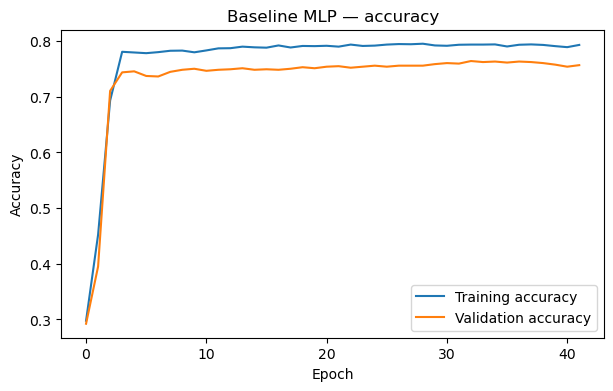

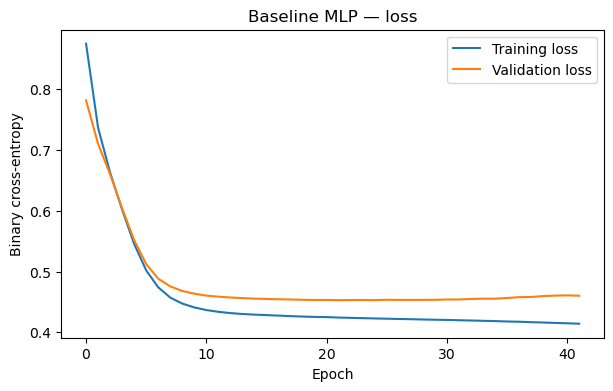

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline MLP — accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Baseline MLP — loss")
plt.legend()
plt.show()

### <font color="#CA3532">Held-out evaluation</font>

This is intentionally different from evaluating on all `X, y`: the test set has not participated in fitting, scaling statistics, or early stopping.

In [21]:
baseline_metrics = solution.evaluate_model(nn, split)
print(baseline_metrics)

assert 0.0 <= baseline_metrics["test_accuracy"] <= 1.0
assert baseline_metrics["test_loss"] >= 0.0

34/34 [==============================] - 0s 762us/step - loss: 0.4836 - accuracy: 0.7290
{'test_loss': 0.48363614082336426, 'test_accuracy': 0.7289546728134155}


In [22]:
print(history.history["accuracy"][-1])
history.history["val_accuracy"][-1]

0.7930290102958679


0.7567067742347717

### <font color="#CA3532">Interpretation</font>

Answer briefly:

1. Do training and validation accuracy follow each other?
2. At what point does validation loss stop improving?
3. Is there evidence of underfitting or overfitting?
4. Why is test accuracy a better final estimate here than accuracy computed on the complete dataset?

1. yes
2. from 5-10 epochs
3. yes overfitting
4. unseen data

### <font color="#CA3532">An architecture improvement</font>

Rather than making the network very large, try two small hidden layers and light dropout.

In [23]:
improved_nn = solution.build_improved_model(split.X_train.shape[1])
improved_history = solution.train_model(
    improved_nn,
    split,
    epochs=250,
    batch_size=32,
    patience=20,
    verbose=0,
)
improved_metrics = solution.evaluate_model(improved_nn, split)

print("Baseline:", baseline_metrics)
print("Improved:", improved_metrics)

assert improved_nn.count_params() > nn.count_params()
assert 0.0 <= improved_metrics["test_accuracy"] <= 1.0

34/34 [==============================] - 0s 662us/step - loss: 0.4853 - accuracy: 0.7660
Baseline: {'test_loss': 0.48363614082336426, 'test_accuracy': 0.7289546728134155}
Improved: {'test_loss': 0.48531395196914673, 'test_accuracy': 0.7659574747085571}


**Question.** Did the slightly larger model actually improve held-out performance?  
Do not conclude that a larger network is automatically better; compare the validation curves and test metric.

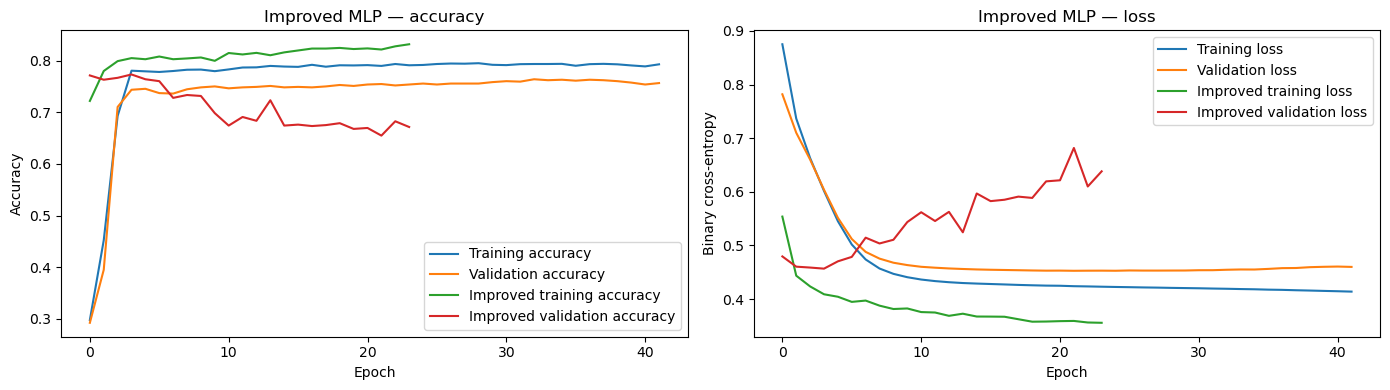

In [24]:
plt.figure(figsize=(14, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.plot(improved_history.history["accuracy"], label="Improved training accuracy")
plt.plot(improved_history.history["val_accuracy"], label="Improved validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved MLP — accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.plot(improved_history.history["loss"], label="Improved training loss")
plt.plot(improved_history.history["val_loss"], label="Improved validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Improved MLP — loss")
plt.legend()

plt.tight_layout()
plt.show()

improved performs worse

# <font color="#CA3532">PART 2 — Optimization methods</font>

### <font color="#CA3532">Regularization and dropout</font>

In [25]:
regularized_nn = solution.build_regularized_model(
    split.X_train.shape[1], l2_strength=1e-4
)
solution.compile_binary_model(
    regularized_nn,
    "adam",
    learning_rate=1e-3,
)

dropout_nn = solution.build_dropout_model(
    split.X_train.shape[1],
    rate=0.25,
)
solution.compile_binary_model(
    dropout_nn,
    "adam",
    learning_rate=1e-3,
)

assert regularized_nn.output_shape[-1] == 1
assert dropout_nn.output_shape[-1] == 1

print("Regularized parameters:", regularized_nn.count_params())
print("Dropout parameters:", dropout_nn.count_params())

Regularized parameters: 737
Dropout parameters: 737


In [26]:
regularized_nn.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 32)                192       
                                                                 
 dense_8 (Dense)             (None, 16)                528       
                                                                 
 dense_9 (Dense)             (None, 1)                 17        
                                                                 
Total params: 737 (2.88 KB)
Trainable params: 737 (2.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


how are parameters calculated?

In [13]:
n_inputs = split.X_train.shape[1] # 5
n_neurons_l1 = 32
n_params_layer1 = n_inputs * n_neurons_l1 + n_neurons_l1
print(n_params_layer1)

n_inputs = n_neurons_l1
n_neurons_l2 = 16
n_params_layer2 = n_inputs * n_neurons_l2 + n_neurons_l2
print(n_params_layer2)

n_inputs = n_neurons_l2
n_neurons_output = 1
n_params_output_layer = n_inputs * n_neurons_output + n_neurons_output
print(n_params_output_layer)
print(n_params_layer1+n_params_layer2+n_params_output_layer)

192
528
17
737


In [14]:
dropout_nn.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 32)                192       
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_9 (Dense)             (None, 16)                528       
                                                                 
 dense_10 (Dense)            (None, 1)                 17        
                                                                 
Total params: 737 (2.88 KB)
Trainable params: 737 (2.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [29]:
def plot_training_history(history, title="Training History"):
    """Plot training and validation accuracy and loss."""
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.title(f"{title} — accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.title(f"{title} — loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

Train both models with `solution.train_model(...)`, plot their validation losses, and compare them with the baseline.

**Question.** Which method appears to reduce overfitting more effectively on this split?

In [30]:
#dropout_nn

regularized_nn_history = solution.train_model(model=regularized_nn, split=split)
regularized_nn_metrics = solution.evaluate_model(regularized_nn, split)

34/34 [==============================] - 0s 503us/step - loss: 0.4874 - accuracy: 0.7595


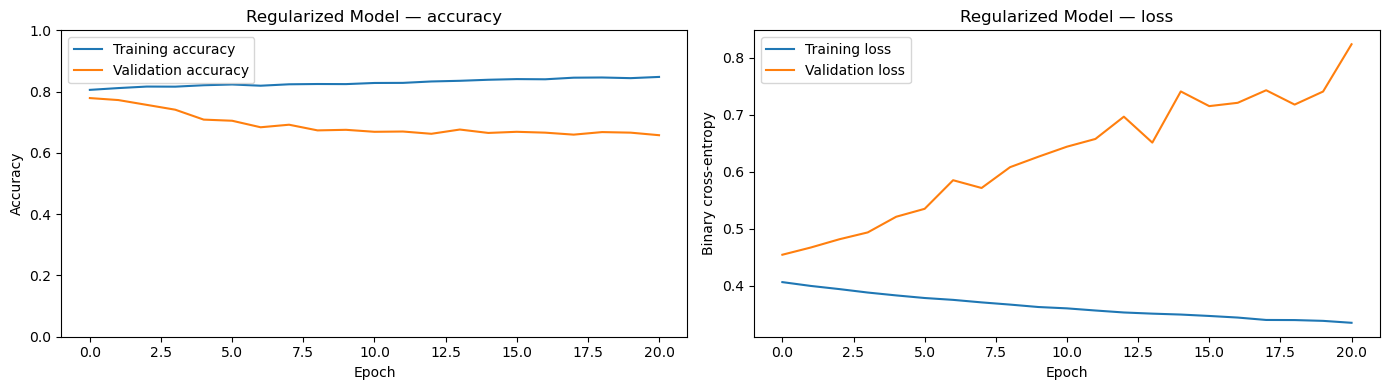

In [31]:
plot_training_history(regularized_nn_history, "Regularized Model")

In [32]:
#dropout_nn

dropout_nn_history = solution.train_model(model=dropout_nn, split=split)
dropout_nn_metrics = solution.evaluate_model(dropout_nn, split)

34/34 [==============================] - 0s 505us/step - loss: 0.4652 - accuracy: 0.7826


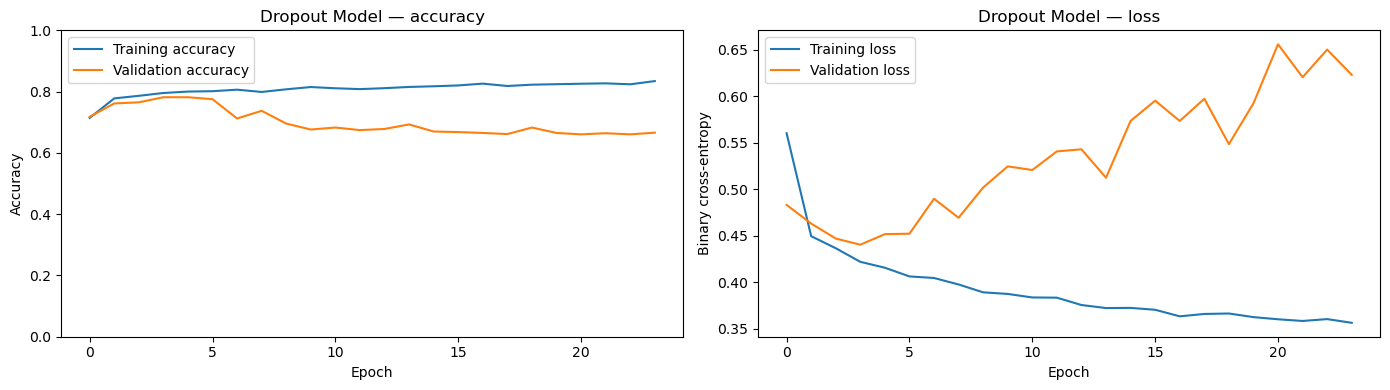

In [33]:
plot_training_history(dropout_nn_history, "Dropout Model")

test for different optimizers

In [34]:
import logging
logging.getLogger('absl').setLevel(logging.ERROR)

In [35]:
optimizer_names = [
    "sgd",
    "momentum",
    "nesterov",
    "adagrad",
    "rmsprop",
    "adam",
]

for name in optimizer_names:
    opt = solution.optimizer_from_name(name, learning_rate=1e-3)
    print(f"{name:10s} -> {opt.__class__.__name__}")

# Tester: every requested optimizer must be constructible
assert len(optimizer_names) == 6

sgd        -> SGD
momentum   -> SGD
nesterov   -> SGD
adagrad    -> Adagrad
rmsprop    -> RMSprop
adam       -> Adam


### <font color="#CA3532">Single optimizer experiment</font>

Before comparing all optimization methods, run one complete experiment with Adam. This verifies the full experiment pipeline for a single optimizer: building the baseline model, selecting the optimizer, training with early stopping, measuring training time, and evaluating the model on the test set.

In [36]:
adam_result = solution.run_optimizer_experiment(
    split,
    optimizer_name="adam",
    epochs=80,
    batch_size=32,
    learning_rate=1e-3,
    patience=10,
    seed=42,
    verbose=0
)

print("Optimizer:", adam_result["optimizer"])
print("Epochs run:", adam_result["epochs_run"])
print("Training time:", round(adam_result["seconds"], 3), "seconds")
print("Test accuracy:", round(adam_result["test_accuracy"], 4))
print("Test loss:", round(adam_result["test_loss"], 4))

assert adam_result["optimizer"] == "adam"
assert adam_result["epochs_run"] <= 80
assert 0.0 <= adam_result["test_accuracy"] <= 1.0

34/34 [==============================] - 0s 467us/step - loss: 0.4863 - accuracy: 0.7641
Optimizer: adam
Epochs run: 20
Training time: 1.743 seconds
Test accuracy: 0.7641
Test loss: 0.4863


### <font color="#CA3532">Fair optimizer comparison</font>

This cell is the most computationally expensive one. Start with `epochs=80`; increase it only if needed. Early stopping records how many epochs were actually required.

In [37]:
results = solution.compare_optimizers(
    split,
    names=optimizer_names,
    #epochs=500,
    epochs=80,
    batch_size=32,
    learning_rate=1e-3,
    #learning_rate=3e-4,
    patience=10,
)

summary = [
    {
        "optimizer": r["optimizer"],
        "epochs": r["epochs_run"],
        "seconds": round(r["seconds"], 3),
        "test_accuracy": round(r["test_accuracy"], 4),
        "test_loss": round(r["test_loss"], 4),
        "history": r["history"],
    }
    for r in results
]

summary

34/34 [==============================] - 0s 479us/step - loss: 0.4863 - accuracy: 0.7641


[{'optimizer': 'sgd',
  'epochs': 80,
  'seconds': 5.759,
  'test_accuracy': 0.7197,
  'test_loss': 0.4933,
  'history': <keras.src.callbacks.History at 0x29a56e9a0>},
 {'optimizer': 'momentum',
  'epochs': 38,
  'seconds': 3.048,
  'test_accuracy': 0.766,
  'test_loss': 0.4791,
  'history': <keras.src.callbacks.History at 0x177163280>},
 {'optimizer': 'nesterov',
  'epochs': 38,
  'seconds': 2.889,
  'test_accuracy': 0.766,
  'test_loss': 0.4791,
  'history': <keras.src.callbacks.History at 0x16e42f2e0>},
 {'optimizer': 'adagrad',
  'epochs': 80,
  'seconds': 5.956,
  'test_accuracy': 0.6318,
  'test_loss': 0.6597,
  'history': <keras.src.callbacks.History at 0x1768c77c0>},
 {'optimizer': 'rmsprop',
  'epochs': 20,
  'seconds': 1.87,
  'test_accuracy': 0.7715,
  'test_loss': 0.4841,
  'history': <keras.src.callbacks.History at 0x17725c2b0>},
 {'optimizer': 'adam',
  'epochs': 20,
  'seconds': 1.723,
  'test_accuracy': 0.7641,
  'test_loss': 0.4863,
  'history': <keras.src.callbacks.Hi

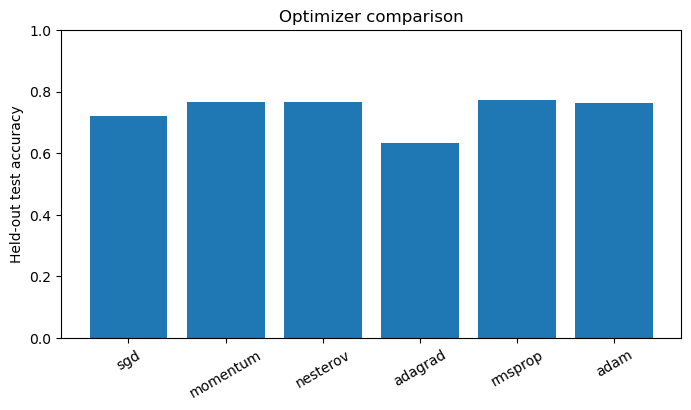

Best on this run: rmsprop | accuracy = 0.7715 | epochs = 20 | seconds = 1.87


In [38]:
names = [r["optimizer"] for r in results]
accuracies = [r["test_accuracy"] for r in results]

plt.figure(figsize=(8, 4))
plt.bar(names, accuracies)
plt.ylim(0, 1)
plt.ylabel("Held-out test accuracy")
plt.title("Optimizer comparison")
plt.xticks(rotation=30)
plt.show()

best = max(results, key=lambda r: r["test_accuracy"])
print(
    "Best on this run:",
    best["optimizer"],
    "| accuracy =", round(best["test_accuracy"], 4),
    "| epochs =", best["epochs_run"],
    "| seconds =", round(best["seconds"], 3),
)

Complex model: Best on this run: adagrad | accuracy = 0.7798 | epochs = 290 | seconds = 29.208  
Simple model: Best on this run: rmsprop | accuracy = 0.7678 | epochs = 62 | seconds = 2.902


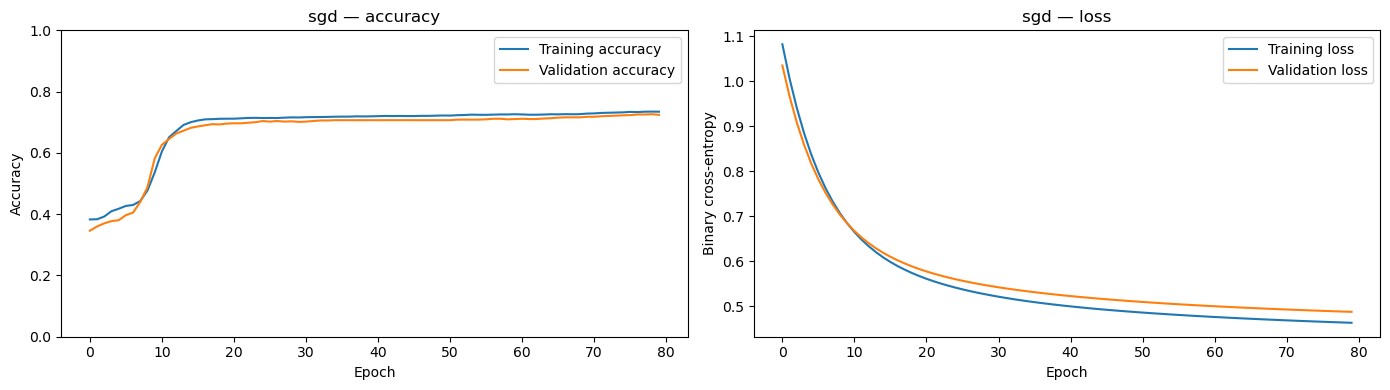

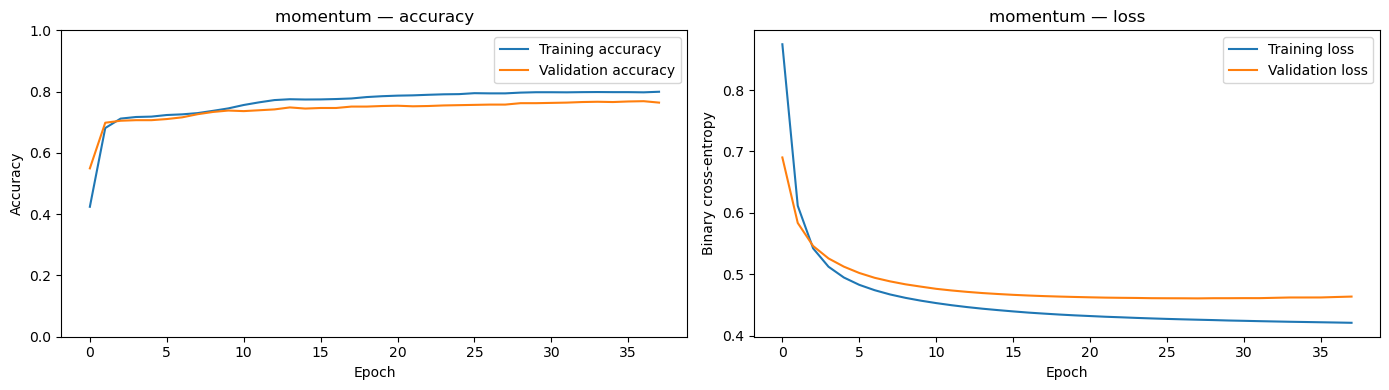

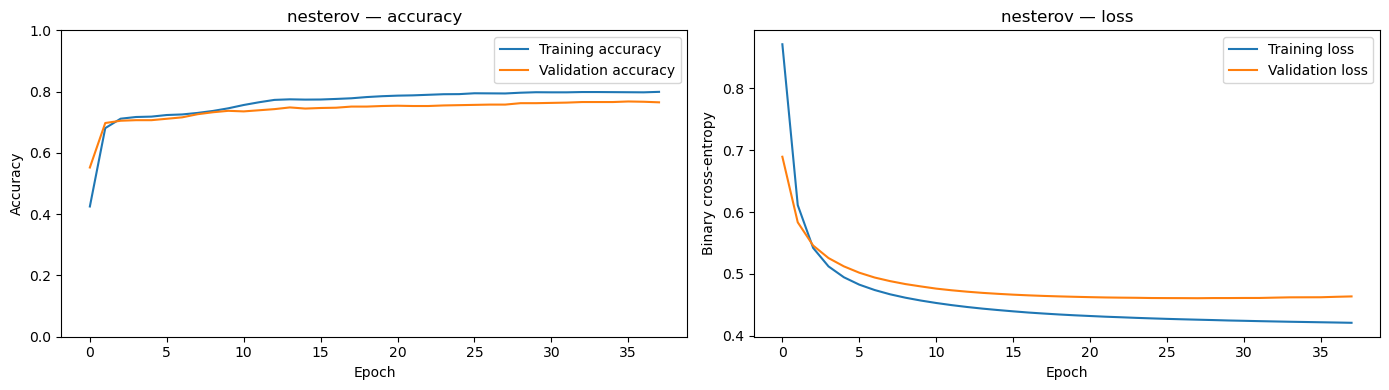

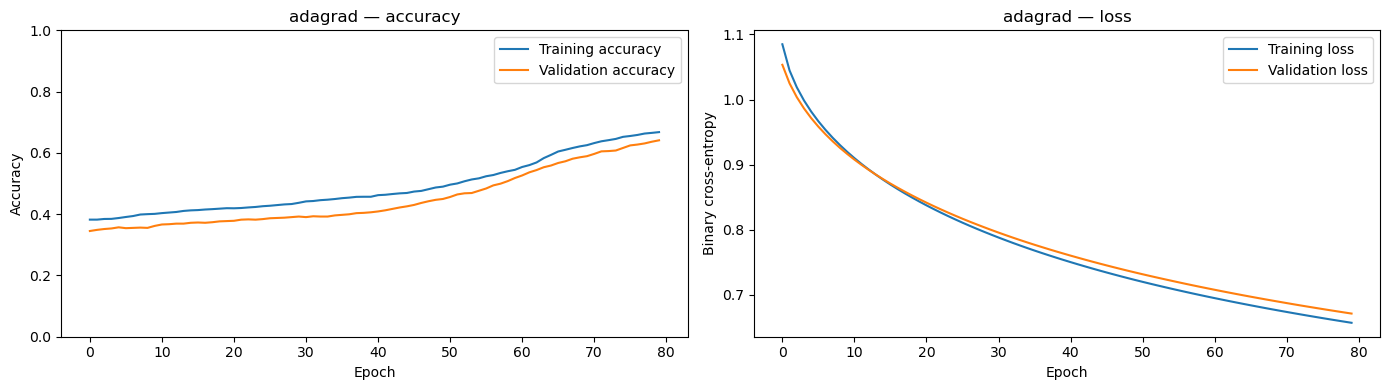

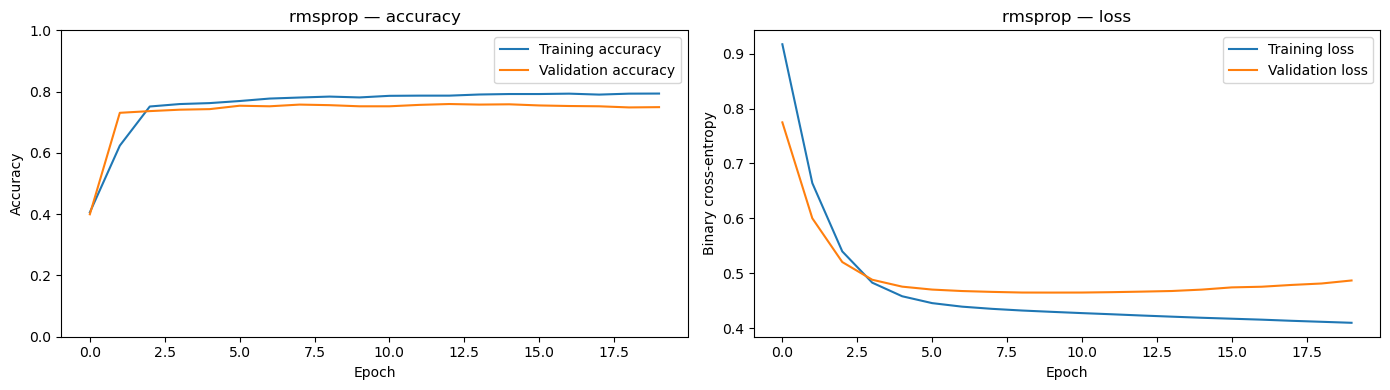

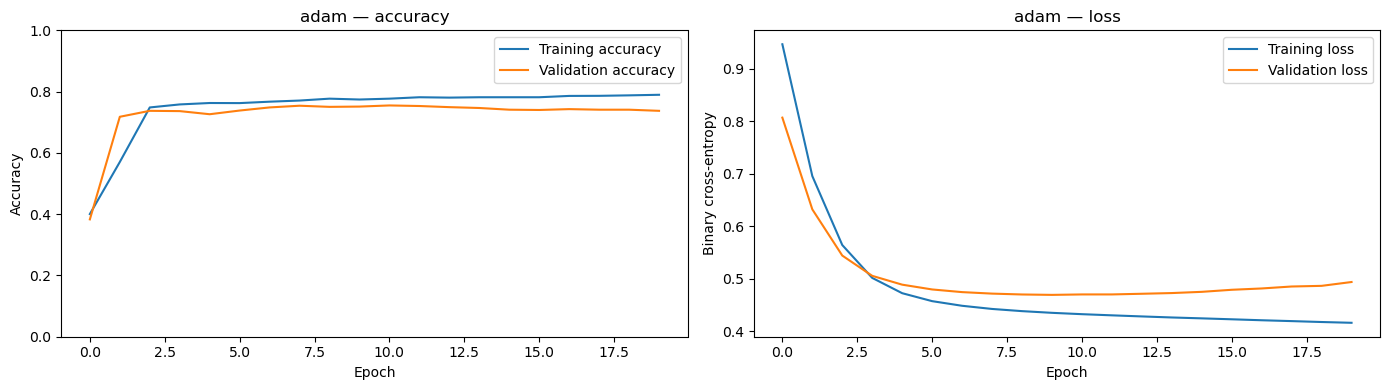

In [39]:
for result in summary:
    plot_training_history(result["history"], title=result["optimizer"])

In [34]:
y_train_int = split.y_train.astype(int)
majority = np.bincount(y_train_int).argmax()
print(np.mean(split.y_val == majority))

0.7067530064754857


### <font color="#CA3532">Optimization discussion</font>

Comment on both **quality** and **cost**:

- Which optimizer reached the best held-out accuracy?
- Which stopped in the fewest epochs?
- Is the fastest wall-clock run also the best?
- Why is it important that all optimizers use the same split, architecture, batch size, stopping rule, and seed?
- What would you change to make this comparison statistically stronger?

### <font color="#CA3532">GPU presence and parallelization</font>

Keras/TensorFlow will normally place supported operations on an available GPU automatically. The first useful check is therefore whether TensorFlow can see a GPU.

In [27]:
devices = solution.available_devices()
print(devices)

if devices["GPU"]:
    print("GPU detected. TensorFlow can use it for supported operations.")
else:
    print("No GPU detected. The lab will run on CPU.")

assert len(devices["CPU"]) >= 1

{'CPU': ['/physical_device:CPU:0'], 'GPU': []}
No GPU detected. The lab will run on CPU.


### <font color="#CA3532">CPU vs GPU timing</font>

For a fair timing exercise, run the same best model twice in environments configured for CPU and GPU respectively, keeping data, seed, architecture, epochs, and batch size fixed.

**Important:** device visibility is generally configured before TensorFlow initializes. In Colab, the cleanest classroom comparison is usually two fresh runtimes (CPU runtime vs GPU runtime), rather than trying to hide/show the GPU halfway through one process.

Record:

| Device | Optimizer | Epochs run | Training seconds | Test accuracy |
|---|---|---:|---:|---:|
| CPU |  |  |  |  |
| GPU |  |  |  |  |

Then explain whether the small MLP is large enough to benefit substantially from GPU overhead.